Comparison of and evaluation of pCO2 products

In [24]:
import numpy as np
import xarray as xr
import pandas as pd
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [2]:
output_dir = '../output-plots/'
pco2_output_dir = "/Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Datasets/Data_Products/CO2_fluxes/Landshuster_Neural/" 
os.path.isdir(pco2_output_dir)

True

In [13]:
# orig_2018_ffn = xr.load_dataset(pco2_output_dir + '/2018_08_30/MPI-SOM_FFN_GCB2018.nc')
som_ffn_names = ['socat_only', 'socat_floats', 'socat_floats_adjusted']

output_names = {'socat_only': 'ffn-output_pco2-estimate_loop_socat_only.nc',
                 'socat_floats': 'ffn-output_pco2-estimate_loop_socat_floats.nc',
                 'socat_floats_adjusted': 'ffn-output_pco2-estimate_loop_socat_floats_adjusted.nc'
}


In [ ]:
som_ffn_output = {}

for name in som_ffn_names:
    som_ffn_output[name] = xr.load_dataset(output_dir + output_names[name])

# socat_only = xr.load_dataset(output_dir + 'ffn-output_pco2-estimate_loop_socat_only.nc')
# socat_floats = xr.load_dataset(output_dir + 'ffn-output_pco2-estimate_loop_socat_floats.nc')
# socat_floats_adjusted = xr.load_dataset(output_dir + 'ffn-output_pco2-estimate_loop_socat_floats_adjusted.nc')


In [110]:
som_ffn_output['socat_only'].sel(time=slice(396, 456)).mean(dim='time')

<xarray.Dataset> Size: 261kB
Dimensions:        (lat: 180, lon: 360)
Coordinates:
  * lat            (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon            (lon) float32 1kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Data variables:
    pco2_estimate  (lat, lon) float32 259kB nan nan nan ... 362.4 362.8 363.3

In [111]:
som_ffn_means = {}
for name in som_ffn_names:
    som_ffn_means[name] = som_ffn_output[name].sel(time=slice(396, 456)).mean(dim='time')

In [18]:
som_ffn_means[name]

<xarray.Dataset> Size: 261kB
Dimensions:        (lat: 180, lon: 360)
Coordinates:
  * lat            (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon            (lon) float32 1kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Data variables:
    pco2_estimate  (lat, lon) float32 259kB nan nan nan ... 317.0 317.3 317.8

## Comparison plots
### Annual Mean

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_16298/1803428742.py:15: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label('pCO2 ($\mu$atm)')
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_16298/1803428742.py:29: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label('pCO2 difference ($\mu$atm)')
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_16298/1803428742.py:38: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label('pCO2 difference ($\mu$atm)')
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_16298/1803428742.py:46

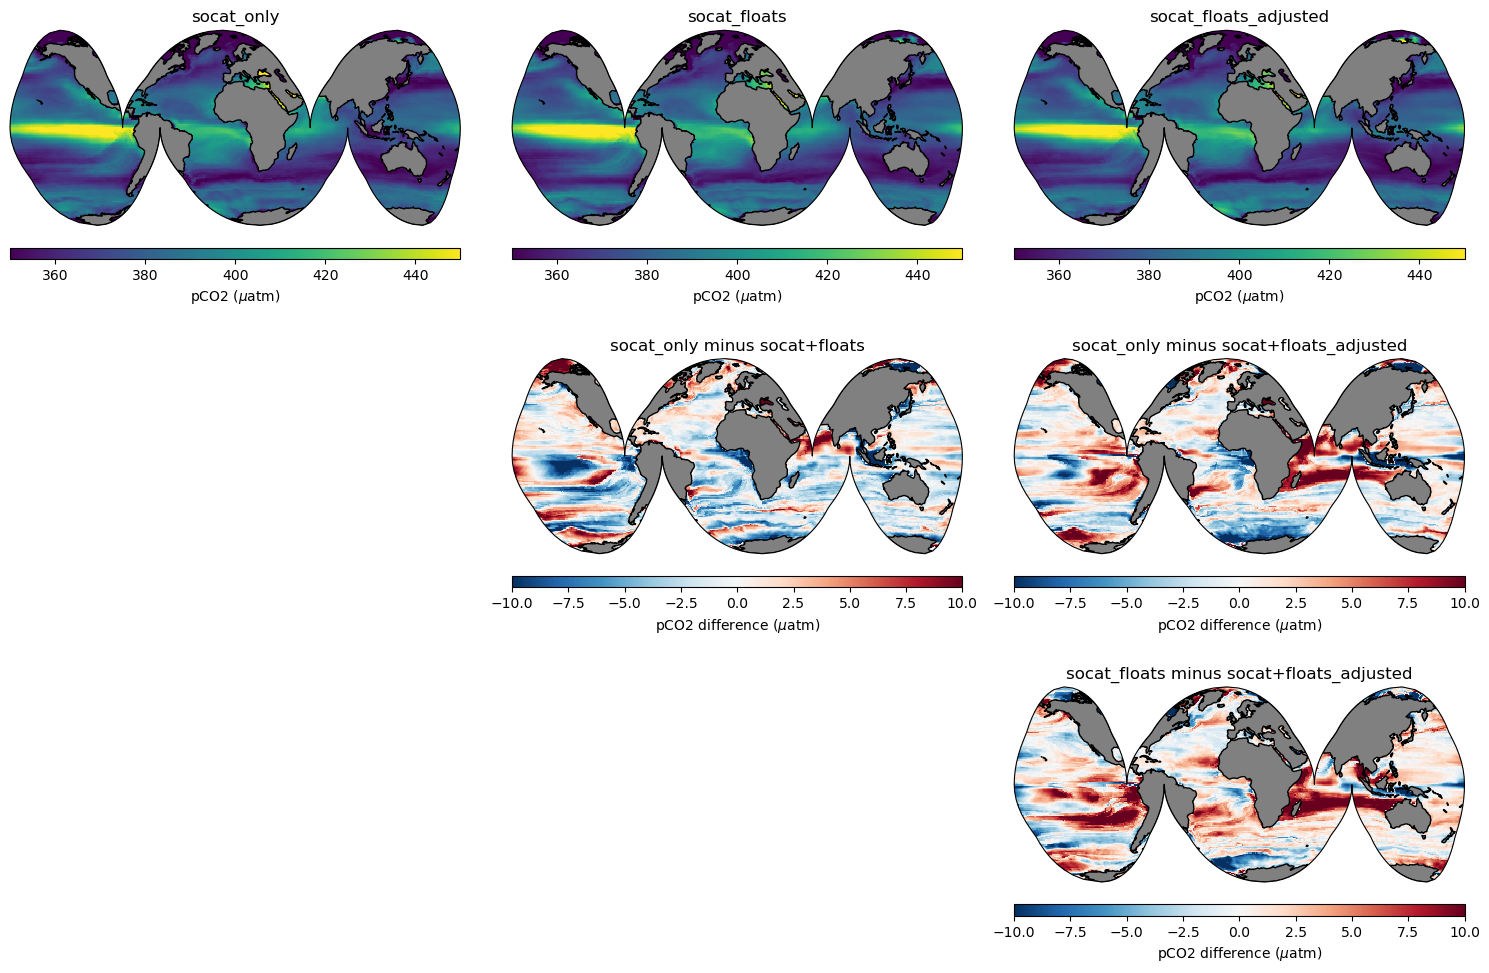

In [121]:
fig = plt.figure(figsize=(15, 10))
y_grid, x_grid = np.meshgrid(som_ffn_output['socat_only']['lat'], som_ffn_output['socat_only']['lon'])
data_proj = ccrs.PlateCarree()
v_min = 350
v_max = 450

for idx, name in enumerate(som_ffn_names):
    ax1 = fig.add_subplot(3,3,idx+1, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=0, globe=None, emphasis='ocean'))
    ax1.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))
    ax1.set_global()
    pmesh = ax1.pcolormesh( x_grid, y_grid,som_ffn_means[name]['pco2_estimate'].T, transform = data_proj, vmin=v_min, vmax=v_max)
    # cbar = fig.colorbar(pmesh, ax=ax, orientation='horizontal')#, fraction=0.1, aspect=40, pad=0.08)
    cbar = fig.colorbar(pmesh, ax=ax1, orientation='horizontal', fraction=0.1, aspect=40, pad=0.08)
    ax1.set_title(name)
    cbar.set_label('pCO2 ($\mu$atm)')

diff_cmap = 'RdBu_r'
# differences
# comparisons = {['socat_only', 'socat_floats'], ['socat_only', 'socat_floats_adjusted']}
v_min_diff = -10
v_max_diff = 10
ax2 = fig.add_subplot(3,3,5, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=0, globe=None, emphasis='ocean'))
ax2.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))
ax2.set_global()
pco2_diff = som_ffn_means['socat_only']['pco2_estimate'] - som_ffn_means['socat_floats']['pco2_estimate']
pmesh = ax2.pcolormesh( x_grid, y_grid, pco2_diff.T, transform = data_proj, vmin=v_min_diff, vmax=v_max_diff, cmap=diff_cmap)
cbar = fig.colorbar(pmesh, ax=ax2, orientation='horizontal', fraction=0.1, aspect=40, pad=0.08)
ax2.set_title('socat_only minus socat+floats')
cbar.set_label('pCO2 difference ($\mu$atm)')

ax2 = fig.add_subplot(3,3,6, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=0, globe=None, emphasis='ocean'))
ax2.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))
ax2.set_global()
pco2_diff = som_ffn_means['socat_only']['pco2_estimate'] - som_ffn_means['socat_floats_adjusted']['pco2_estimate']
pmesh = ax2.pcolormesh( x_grid, y_grid, pco2_diff.T, transform = data_proj, vmin=v_min_diff, vmax=v_max_diff, cmap=diff_cmap)
cbar = fig.colorbar(pmesh, ax=ax2, orientation='horizontal', fraction=0.1, aspect=40, pad=0.08)
ax2.set_title('socat_only minus socat+floats_adjusted')
cbar.set_label('pCO2 difference ($\mu$atm)')

ax2 = fig.add_subplot(3,3,9, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=0, globe=None, emphasis='ocean'))
ax2.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))
ax2.set_global()
pco2_diff = som_ffn_means['socat_floats']['pco2_estimate'] - som_ffn_means['socat_floats_adjusted']['pco2_estimate']
pmesh = ax2.pcolormesh( x_grid, y_grid, pco2_diff.T, transform = data_proj, vmin=v_min_diff, vmax=v_max_diff, cmap=diff_cmap)
cbar = fig.colorbar(pmesh, ax=ax2, orientation='horizontal', fraction=0.1, aspect=40, pad=0.08)
cbar.set_label('pCO2 difference ($\mu$atm)')
ax2.set_title('socat_floats minus socat+floats_adjusted')

plt.tight_layout()
plt.savefig(output_dir + 'annual_mean/annual_mean_differences.png' )


### Annual mean zonal differences

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_16298/2172799069.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('pCO2 differences ($\mu$atm)')


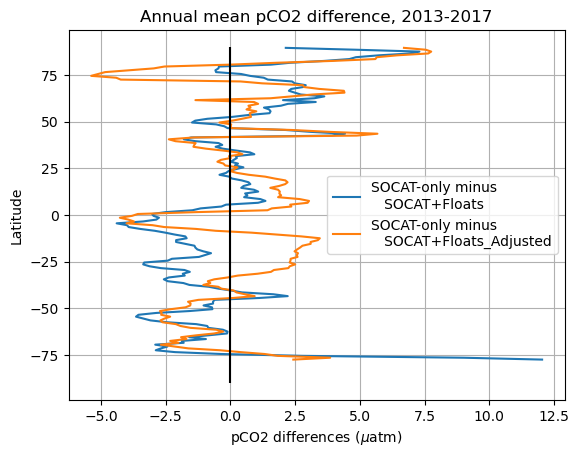

In [120]:
pco2_diff = som_ffn_means['socat_only'].mean(dim='lon') - som_ffn_means['socat_floats'].mean(dim='lon')
plt.plot(pco2_diff['pco2_estimate'], som_ffn_means['socat_only']['lat'], label='SOCAT-only minus\n   SOCAT+Floats')
plt.grid('on')
pco2_diff = som_ffn_means['socat_only'].mean(dim='lon') - som_ffn_means['socat_floats_adjusted'].mean(dim='lon')
plt.plot(pco2_diff['pco2_estimate'], som_ffn_means['socat_only']['lat'], label='SOCAT-only minus\n   SOCAT+Floats_Adjusted')
plt.legend()
plt.vlines(ymin=-90, ymax=90, x=0, colors='black')
plt.xlabel('pCO2 differences ($\mu$atm)')
plt.ylabel('Latitude')
plt.title('Annual mean pCO2 difference, 2013-2017')
plt.savefig(output_dir + 'annual_mean/annual_mean_zonal_differences.png' )


### Seasonal differences

In [66]:
# get a real time vector from the original gridded data file
time_vec = xr.open_dataset(output_dir + '../input-data/socat_only_1970_2017.nc')['tmnth']

In [80]:
time_pd = pd.to_datetime(time_vec.values)
NH_sum = [5,6,7,8,9,10]
NH_wint = [11, 12, 1, 2, 3, 4]

NH_sum_index = time_pd.month>13
for m in NH_sum:
    NH_sum_index = np.logical_or(time_pd.month==m, NH_sum_index)

NH_wint_index = time_pd.month>13
for m in NH_wint:
    NH_wint_index = np.logical_or(time_pd.month==m, NH_wint_index)


In [82]:
NH_sum_index

array([False, False, False, False,  True,  True,  True,  True,  True,
        True, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False,  True,  True,  True,  True,  True,
        True, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False,  True,  True,  True,  True,  True,
        True, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False,  True,  True,  True,  True,  True,
        True, False, False, False, False, False, False,  True,  True,
        True,  True,

In [93]:
pCO2_diff = som_ffn_output['socat_only']['pco2_estimate'][NH_sum_index,:,:] - som_ffn_output['socat_floats']['pco2_estimate'][NH_sum_index,:,:]
pCO2_diff_mean = pCO2_diff.mean(dim='time')
pco2_diff_zonal = pCO2_diff_mean.mean(dim='lon')

In [97]:
pco2_diff_zonal.values

array([            nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
        2.20186996e+01,  2.05333042e+01,  1.02559290e+01,  6.64708996e+00,
        4.37844133e+00,  2.90665865e+00,  4.85425377e+00,  5.25372887e+00,
        4.98658419e+00,  5.64387703e+00,  4.86997890e+00,  4.56696367e+00,
        2.37502933e+00,  2.40007544e+00,  2.31061912e+00,  2.13339734e+00,
        2.00095654e+00,  1.96805251e+00,  2.24225640e+00,  2.10607815e+00,
        1.16985190e+00,  5.78468084e-01,  1.01346707e+00,  7.84370184e-01,
        8.73228252e-01,  9.63117540e-01,  1.12171352e+00,  1.55107307e+00,
        6.15189910e-01, -2.58320242e-01, -2.41830256e-02,  1.76710144e-01,
       -9.09222364e-01, -2.15339780e+00, -3.28998685e+00, -2.94643688e+00,
       -2.55582023e+00, -2.38400507e+00, -1.97791862e+00, -1.73786950e+00,
       -1.61363709e+00, -

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_16298/282827123.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('pCO2 ($\mu$atm)')
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_16298/282827123.py:34: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('pCO2 ($\mu$atm)')


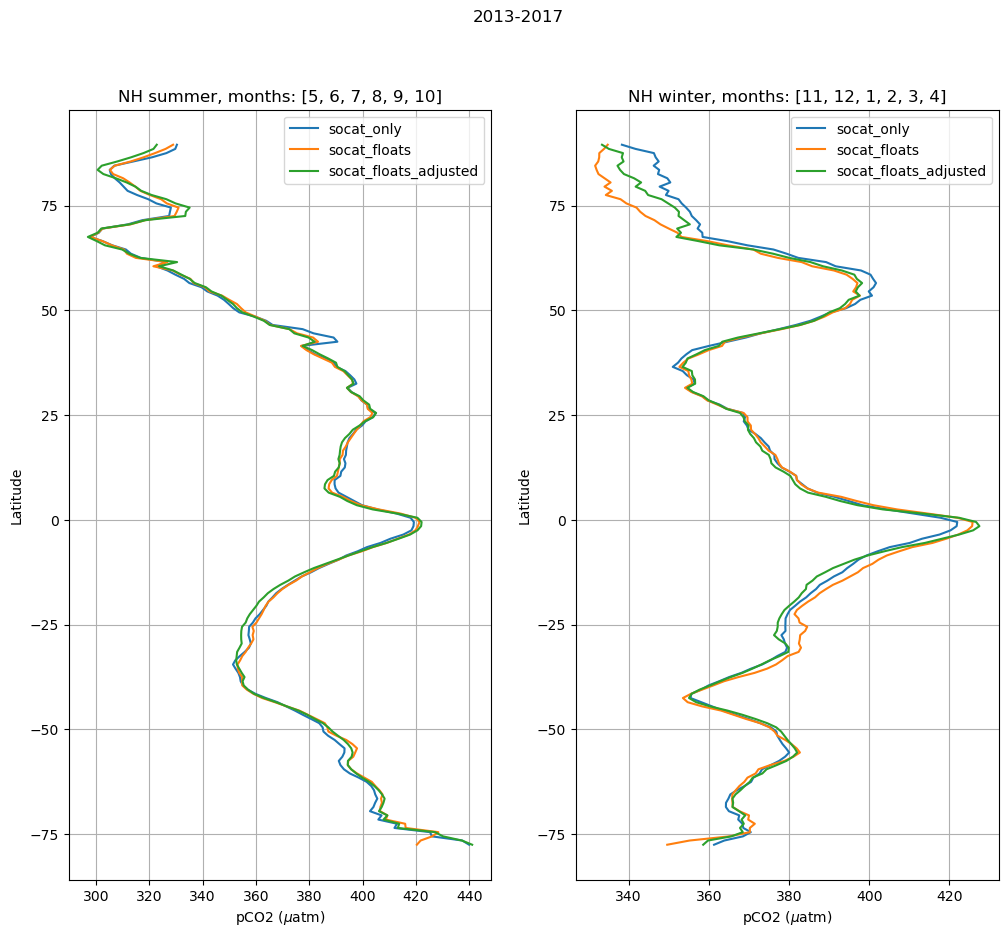

In [127]:
fig = plt.figure(figsize=(12, 10))

fig.add_subplot(1,2,1)
for name in som_ffn_names:
    pCO2 = som_ffn_output[name]['pco2_estimate'][NH_sum_index,:,:]
    pCO2_mean = pCO2.sel(time=slice(396, 456)).mean(dim='time')
    pco2_zonal = pCO2_mean.mean(dim='lon')
    # plt.vlines(ymin=-90, ymax=90, x=0, colors='black')
    plt.plot(pco2_zonal.values, som_ffn_means['socat_only']['lat'], label=name)
    plt.grid('on')

# pCO2_diff = som_ffn_output['socat_only']['pco2_estimate'][NH_sum_index,:,:] - som_ffn_output['socat_floats_adjusted']['pco2_estimate'][NH_sum_index,:,:]
# pCO2_diff_mean = pCO2_diff.mean(dim='time')
# pco2_diff_zonal = pCO2_diff_mean.mean(dim='lon')

# pco2_diff = som_ffn_means['socat_only'].mean(dim='lon') - som_ffn_means['socat_floats_adjusted'].mean(dim='lon')
# plt.plot(pco2_diff['pco2_estimate'], som_ffn_means['socat_only']['lat'], label='SOCAT-only minus SOCAT+Floats_Adjusted')
plt.title('NH summer, months: ' + str(NH_sum))
plt.legend()
plt.xlabel('pCO2 ($\mu$atm)')
plt.ylabel('Latitude')

fig.add_subplot(1,2,2)
for name in som_ffn_names:
    pCO2 = som_ffn_output[name]['pco2_estimate'][NH_wint_index,:,:]
    pCO2_mean = pCO2.sel(time=slice(396, 456)).mean(dim='time')
    pco2_zonal = pCO2_mean.mean(dim='lon')
    # plt.vlines(ymin=-90, ymax=90, x=0, colors='black')
    plt.plot(pco2_zonal.values, som_ffn_means['socat_only']['lat'], label=name)
    plt.grid('on')

    plt.title('NH winter, months: ' + str(NH_wint))
plt.legend()
plt.xlabel('pCO2 ($\mu$atm)')
plt.ylabel('Latitude')
fig.suptitle('2013-2017')
plt.savefig(output_dir + 'annual_mean/seasonal_mean_zonal_pco2.png' )


<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_16298/1906922868.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('pCO2 differences ($\mu$atm)')


Text(0, 0.5, 'Latitude')

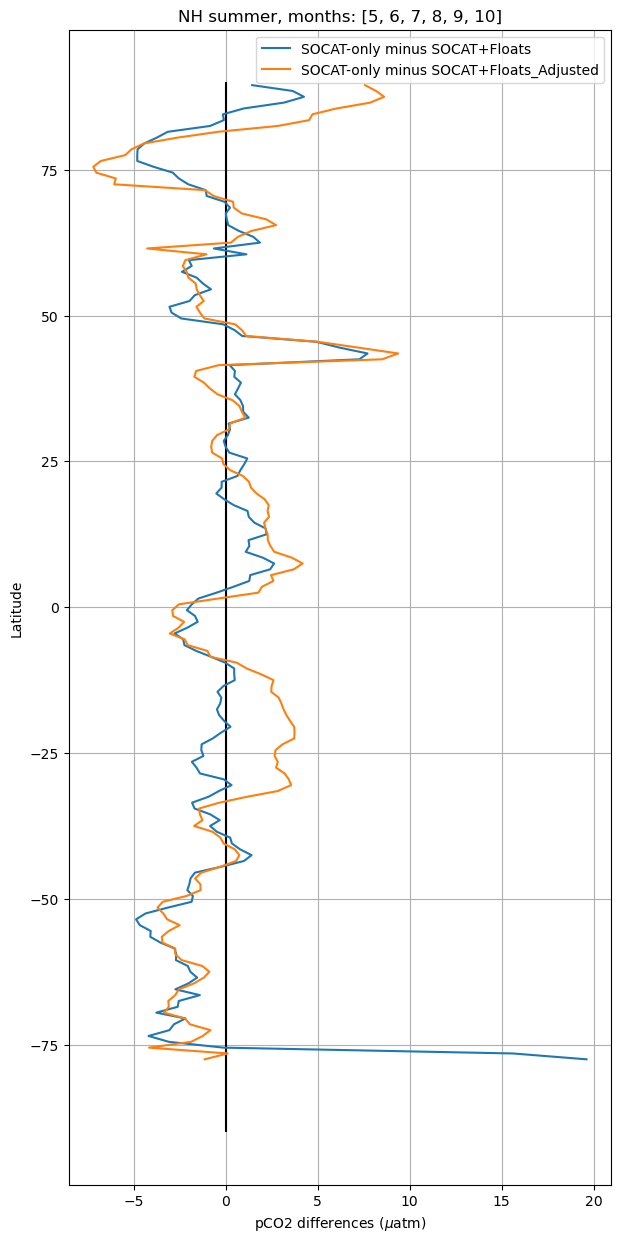

In [ ]:

fig = plt.figure(figsize=(12, 10))

fig.add_subplot(1,2,1)

pCO2_diff = som_ffn_output['socat_only']['pco2_estimate'][NH_sum_index,:,:] - som_ffn_output['socat_floats']['pco2_estimate'][NH_sum_index,:,:]
pCO2_diff_mean = pCO2_diff.sel(time=slice(396, 456)).mean(dim='time')
pco2_diff_zonal = pCO2_diff_mean.mean(dim='lon')
plt.vlines(ymin=-90, ymax=90, x=0, colors='black')
plt.plot(pco2_diff_zonal.values, som_ffn_means['socat_only']['lat'], label='SOCAT-only minus SOCAT+Floats')
plt.grid('on')

pCO2_diff = som_ffn_output['socat_only']['pco2_estimate'][NH_sum_index,:,:] - som_ffn_output['socat_floats_adjusted']['pco2_estimate'][NH_sum_index,:,:]
pCO2_diff_mean = pCO2_diff.sel(time=slice(396, 456)).mean(dim='time')
pco2_diff_zonal = pCO2_diff_mean.mean(dim='lon')

pco2_diff = som_ffn_means['socat_only'].mean(dim='lon') - som_ffn_means['socat_floats_adjusted'].mean(dim='lon')
plt.plot(pco2_diff_zonal.values, som_ffn_means['socat_only']['lat'], label='SOCAT-only minus SOCAT+Floats_Adjusted')
plt.title('NH summer, months: ' + str(NH_sum))
plt.legend()
plt.xlabel('pCO2 differences ($\mu$atm)')
plt.ylabel('Latitude')


fig.add_subplot(1,2,2)

pCO2_diff = som_ffn_output['socat_only']['pco2_estimate'][NH_wint_index,:,:] - som_ffn_output['socat_floats']['pco2_estimate'][NH_wint_index,:,:]
pCO2_diff_mean = pCO2_diff.sel(time=slice(396, 456)).mean(dim='time')
pco2_diff_zonal = pCO2_diff_mean.mean(dim='lon')
plt.vlines(ymin=-90, ymax=90, x=0, colors='black')
plt.plot(pco2_diff_zonal.values, som_ffn_means['socat_only']['lat'], label='SOCAT-only minus SOCAT+Floats')
plt.grid('on')

pCO2_diff = som_ffn_output['socat_only']['pco2_estimate'][NH_wint_index,:,:] - som_ffn_output['socat_floats_adjusted']['pco2_estimate'][NH_wint_index,:,:]
pCO2_diff_mean = pCO2_diff.sel(time=slice(396, 456)).mean(dim='time')
pco2_diff_zonal = pCO2_diff_mean.mean(dim='lon')

pco2_diff = som_ffn_means['socat_only'].mean(dim='lon') - som_ffn_means['socat_floats_adjusted'].mean(dim='lon')
plt.plot(pco2_diff_zonal.values, som_ffn_means['socat_only']['lat'], label='SOCAT-only minus SOCAT+Floats_Adjusted')
plt.title('NH summer, months: ' + str(NH_sum))
plt.legend()
plt.xlabel('pCO2 differences ($\mu$atm)')
plt.ylabel('Latitude')

fig.suptitle('2013-2017')
plt.savefig(output_dir + 'annual_mean/seasonal_mean_zonal_pco2_differences.png' )


In [56]:
pco2_diff

<xarray.Dataset> Size: 1kB
Dimensions:        (lat: 180)
Coordinates:
  * lat            (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
Data variables:
    pco2_estimate  (lat) float32 720B nan nan nan nan ... 7.141 4.722 2.813

In [ ]:
som_ffn_means[name]['pco2_estimate'].plot.pcolormesh(vmin=300, vmax=500)


In [45]:
som_ffn_trimmed = som_ffn.where(som_ffn['time']>23, drop=True)
som_ffn_trimmed

<xarray.Dataset> Size: 112MB
Dimensions:        (time: 432, lat: 180, lon: 360)
Coordinates:
  * time           (time) int32 2kB 24 25 26 27 28 29 ... 451 452 453 454 455
  * lon            (lon) float32 1kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * lat            (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
Data variables:
    pco2_estimate  (time, lat, lon) float32 112MB nan nan nan ... nan nan nan

In [46]:
som_ffn_mean = som_ffn_trimmed.mean(dim='time')

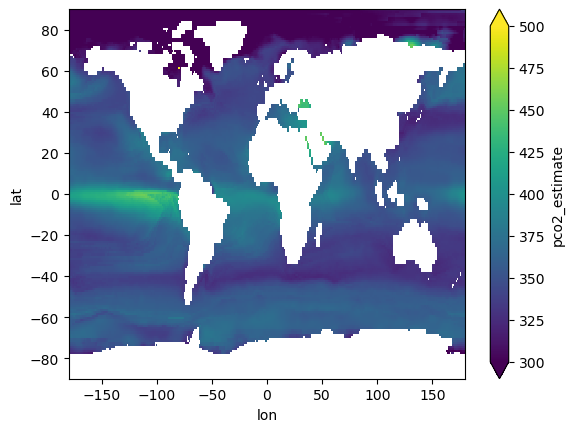

In [47]:
som_ffn_mean['pco2_estimate'].plot.pcolormesh(vmin=300, vmax=500)


In [23]:
orig_2018_ffn

<xarray.Dataset> Size: 448MB
Dimensions:         (time: 432, lat: 180, lon: 360, bnds: 2, date: 6)
Coordinates:
  * time            (time) datetime64[ns] 3kB 1982-01-15 ... 2017-12-15
  * lat             (lat) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon             (lon) float32 1kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
    date            (time, date) float32 10kB 1.982e+03 1.0 15.0 ... 0.0 0.0 0.0
Dimensions without coordinates: bnds
Data variables:
    spco2           (time, lat, lon) float32 112MB 1e+20 1e+20 ... 1e+20 1e+20
    fgco2           (time, lat, lon) float32 112MB 1e+20 1e+20 ... 1e+20 1e+20
    spco2_smoothed  (time, lat, lon) float32 112MB 1e+20 1e+20 ... 1e+20 1e+20
    fgco2_smoothed  (time, lat, lon) float32 112MB 1e+20 1e+20 ... 1e+20 1e+20
    seamask         (lat, lon) int32 259kB 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1
    time_bnds       (time, bnds) datetime64[ns] 7kB 1981-12-31 ... 2017-12-31
    lat_bnds        (lat, bnds) float32 1kB -90.0 -89.0 -89.0 ... 89.0 89.0 90.0
    lon_bnds        (lon, bnds) float32 3kB -180.0 -179.0 -179.0 ... 179.0 180.0
Attributes:
    institution:    Max Planck Institute for Meteorology, Hamburg, Germany
    institude_id:   MPI-M
    model_id:       SOM-FFN
    run_id:         SOM_FFN_GCB2018
    contact:        Peter Landschutzer (Peter.Landschuetzer@mpimet.mpg.de)
    creation_date:  2018-07-12

In [33]:
orig_2018_ffn_masked = orig_2018_ffn.where(orig_2018_ffn['spco2']<10000)
orig_2018_ffn_masked

<xarray.Dataset> Size: 2GB
Dimensions:         (time: 432, lat: 180, lon: 360, bnds: 2, date: 6)
Coordinates:
  * time            (time) datetime64[ns] 3kB 1982-01-15 ... 2017-12-15
  * lat             (lat) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon             (lon) float32 1kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
    date            (time, date) float32 10kB 1.982e+03 1.0 15.0 ... 0.0 0.0 0.0
Dimensions without coordinates: bnds
Data variables:
    spco2           (time, lat, lon) float32 112MB nan nan nan ... nan nan nan
    fgco2           (time, lat, lon) float32 112MB nan nan nan ... nan nan nan
    spco2_smoothed  (time, lat, lon) float32 112MB nan nan nan ... nan nan nan
    fgco2_smoothed  (time, lat, lon) float32 112MB nan nan nan ... nan nan nan
    seamask         (lat, lon, time) float64 224MB nan nan nan ... nan nan nan
    time_bnds       (time, bnds, lat, lon) datetime64[ns] 448MB NaT NaT ... NaT
    lat_bnds        (lat, bnds, time, lon) float32 224MB nan nan nan ... nan nan
    lon_bnds        (lon, bnds, time, lat) float32 224MB nan nan nan ... nan nan
Attributes:
    institution:    Max Planck Institute for Meteorology, Hamburg, Germany
    institude_id:   MPI-M
    model_id:       SOM-FFN
    run_id:         SOM_FFN_GCB2018
    contact:        Peter Landschutzer (Peter.Landschuetzer@mpimet.mpg.de)
    creation_date:  2018-07-12

In [34]:
orig_2018_ffn_masked = orig_2018_ffn_masked['spco2'].mean(dim='time')
orig_2018_ffn_masked

<xarray.DataArray 'spco2' (lat: 180, lon: 360)> Size: 259kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(180, 360), dtype=float32)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5

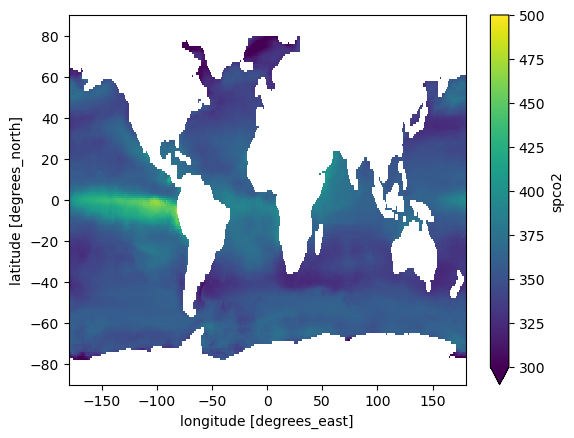

In [36]:
orig_2018_ffn_masked.plot.pcolormesh(vmin=300, vmax=500)

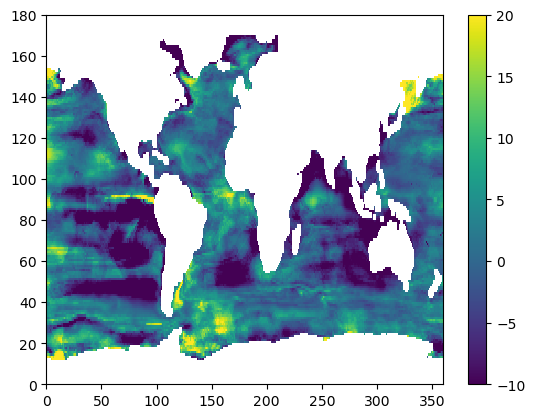

In [56]:
plt.pcolormesh(som_ffn_mean['pco2_estimate'] - orig_2018_ffn_masked, vmin=-10, vmax=20)
plt.colorbar()